In [1]:
## 경고 제거##
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

## DataFrame & visual option ##
import pandas as pd
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.set_option('display.max_columns', None)

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
import folium
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
mts = pd.read_csv('../../../011.데이터/03.MTS/230920_교통과학장비 설치정보_경기남부.csv')
taas = pd.read_csv('../../../011.데이터/01.TAAS/TAAS데이터/taas001h_2018_2022.csv')
sltd = gpd.read_file('./tohome/ACC_SLTD_WITH_EQID_FINAL.geojson')

tmp = pd.read_excel('../../../011.데이터/01.TAAS/TAAS데이터/tass_code.xlsx')

sltd.columns = [{key:value for key,value in zip(tmp['영문컬럼'],tmp['컬럼명'])}.get(x) for x in sltd.columns]

tmplist = sltd.columns.to_list()

tmplist[6] = '발생위치경도'
tmplist[7] = '발생위치위도'
tmplist[-3] = '과속사고여부(2021~)'
tmplist[-2] = '장비번호'
tmplist[-1] = 'geometry'

sltd.columns = tmplist
sltd = pd.merge(sltd,mts,left_on='장비번호',right_on='장비번호')
sltd.columns = [x.replace('*','') for x in sltd.columns]

In [5]:
mts.head()

,장비번호,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호,노선명,특정도로,도로유형,도로선형,조명장치
0,F8973,속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,과천시 주암동 555(과천-봉담간고속화도로)(국립과천과학관->선암IC),30.6,과천경찰서,37.453249,127.015806,37.445403,127.004304,2.0,루프센서,1.0,2.0,80,80,95.0,95.0,지방도,309,지방도309(우면산로),NaN,단일로,직선평지,NaN
1,F8978,속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,시흥시 장곡동 432 삼환(아) 106동 앞(월곶→목감),35.0,시흥경찰서,37.383119,126.785930,37.382345,126.774129,2.0,루프센서,1.0,2.0,70,70,85.0,85.0,시도,0,지방도(동서로),NaN,단일로,직선내리막,NaN
2,F8979,속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,안성시 죽산면 장계리 18-3(광혜원→죽산면사무소),42.0,안성경찰서,37.059917,127.410736,37.052061,127.410967,2.0,루프센서,1.0,1.0,60,60,71.0,71.0,시도,0,국지도82(걸미로),NaN,단일로,직선내리막,NaN
3,F8980,속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,오산시 세교동 446 광성초교앞삼거리(평택→수원),12.0,오산경찰서,37.183296,127.039427,37.172208,127.041714,2.0,루프센서,1.0,3.0,70,70,85.0,85.0,시도,0,지방도(서부로),NaN,단일로,직선내리막,NaN
4,F8983,속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,평택시 안중읍 용성리 501-4 용성3리입구(청북면→안중읍),39.9,평택경찰서,37.015095,126.945809,37.028869,126.941244,2.0,루프센서,1.0,2.0,70,70,85.0,85.0,국도,39,국도39,NaN,단일로,직선평지,NaN


In [7]:
mts.columns

Index(['장비번호', '장비종류', '단속형태', '납품업체', '제조업체', '제조번호', '최초운영일자', '장비규격',
       '구간그룹명', '지방청', '자산구분', '관리·설치일', '설치구분/지자체명', '관리종료일', '종료구분', '관리이관',
       '설치(이전)회차', '설치일자', '설치장소', '센터와의거리', '관할서', '제어기 위도', '제어기 경도',
       '표지판 위도', '표지판 경도', '표지판 개수', '차량검지', '설치·단속 차로수', '도로차로수(편도)',
       '제한속도(소형)', '제한속도(대형)', '단속속도(소형)', '단속속도(대형)', '도로종류', '노선번호', '노선명',
       '특정도로', '도로유형', '도로선형', '조명장치'],
      dtype='object')

In [4]:
mts.columns = [x.replace('*','') for x in mts.columns]

단속형태
구간과속    96
Name: count, dtype: int64

In [22]:
mts[mts['구간그룹명'].str.contains('동수원',na=False)]

,장비번호,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호,노선명,특정도로,도로유형,도로선형,조명장치
1130,G4425,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,"영동고속도로 51.2km 시점 1,2차로(용인IC->동수원IC)(용인시 유방동 66...",29.0,１지구대,37.262331,127.197737,37.259292,127.204140,2.0,레이다센서,2.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN
1131,G4426,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,"영동고속도로 51.2km 시점 3,4차로(용인IC->동수원IC)(용인시 유방동 66...",29.0,１지구대,37.262331,127.197737,37.259258,127.204054,2.0,레이다센서,2.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN
1132,G4427,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,영동고속도로 51.2km 시점 5차로(용인IC→동수원IC)(용인시 유방동 667-1),29.0,１지구대,37.262331,127.197737,37.259258,127.204011,2.0,레이다센서,1.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN
1133,G4428,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,"영동고속도로 42.9km 종점 1,2차로(용인IC->동수원IC)(용인시 언남동 44...",20.0,１지구대,37.291722,127.115698,37.290647,127.125016,2.0,레이다센서,2.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN
1134,G4429,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,"영동고속도로 42.9km 종점 3,4차로(용인IC→동수원IC)(용인시 언남동 440-2)",20.0,１지구대,37.291722,127.115698,37.290681,127.124973,2.0,레이다센서,2.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN
1135,G4430,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2020-05-27,('17.03) -아,영동고속도로(용인IC->동수원IC)(용인시),경기남부,지자체,2020-05-27,용인시,NaN,NaN,NaN,1,2020-05-27,영동고속도로 42.9km 종점 5차로(용인IC→동수원IC)(용인시 언남동 440-2),20.0,１지구대,37.291722,127.115698,37.290613,127.124973,2.0,레이다센서,1.0,5.0,100,80,122.0,102.0,고속도로,50,영동고속도로,NaN,단일로,직선평지,NaN


In [ ]:
mts[~mts['구간그룹명'].isna()]

In [30]:
tmp = gpd.read_file('../../../011.데이터/09.ETC/nearst_link.geojson')
link = gpd.read_file('../../../011.데이터/09.ETC/[2023-09-22]NODELINKDATA/MOCT_LINK.shp',encoding='cp949')

In [45]:
node = gpd.read_file('../../../011.데이터/09.ETC/[2023-09-22]NODELINKDATA/MOCT_NODE.shp',encoding='cp949')

In [57]:
link = link.to_crs(epsg=4326)

In [94]:
link['start_pnt']= link['geometry'].apply(lambda x: x.coords[0])
link['end_pnt']= link['geometry'].apply(lambda x: x.coords[-1])

In [97]:
tmp.groupby(['구간그룹명','HubName'],as_index=False).agg({'장비번호':'count'})

,구간그룹명,HubName,장비번호
0,경부고속도로390,2060358300,3
1,경부고속도로390,2440069800,3
2,경부하행,2230344300,3
3,경부하행,2310029700,3
4,김포 걸포동(서울->강화),2320087800,3
5,김포 걸포동(서울->강화),2320088100,3
6,김포 고촌읍(강화->서울),2320087800,1
7,김포 고촌읍(강화->서울),2320087900,2
8,김포 고촌읍(강화->서울),2320088100,3
9,김포시 고촌읍 신곡리(서울->강화),2320132300,3


In [102]:
tmplink = pd.merge(tmp,link,left_on = 'HubName', right_on = 'LINK_ID', how='left')

In [ ]:
for i in tmplink['구간그룹명'].unique():
    st_sltd_pnt = tmplink[tmplink['구간그룹명'] == i][['장비번호','구간그룹명','start_pnt','end_pnt']].sort_values('장비번호').reset_index(drop= True).iloc[0,3]
    ed_sltd_pnt = tmplink[tmplink['구간그룹명'] == i][['장비번호','구간그룹명','start_pnt','end_pnt']].sort_values('장비번호').reset_index(drop= True).iloc[-1,2]
    display(link[(link['start_pnt'] == st_sltd_pnt)&(link['end_pnt'] == st_sltd_pnt)])



In [156]:
link['LINK_ID'] = link['LINK_ID'].astype('int')

In [158]:
gg_link = link[link['LINK_ID'].between(2000000000,2499999999)]

In [160]:
link

,LINK_ID,F_NODE,T_NODE,LANES,ROAD_RANK,ROAD_TYPE,ROAD_NO,ROAD_NAME,ROAD_USE,MULTI_LINK,CONNECT,MAX_SPD,REST_VEH,REST_W,REST_H,C-ITS,LENGTH,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK,geometry,start_pnt,end_pnt
0,3270291800,3270103900,3270103700,1,107,000,-,도민길,0,0,0,50,0,0,0,0,187.265435,20230519,NaN,NaN,NaN,"LINESTRING (126.79930 35.02167, 126.79919 35.0...","(126.79930265837649, 35.02167410612718)","(126.79893755199015, 35.0233264194225)"
1,1961119000,1960069303,1960434700,1,104,000,-,북문4길,0,0,0,50,0,0,0,0,64.447604,20230519,NaN,NaN,NaN,"LINESTRING (129.12463 35.57001, 129.12466 35.5...","(129.12463000843974, 35.57000566219829)","(129.12465798024007, 35.570585812062404)"
2,2560636102,2560282801,2560282700,1,106,000,424,미근로,0,0,0,60,0,0,0,0,182.534920,20230519,NaN,NaN,NaN,"LINESTRING (129.18165 37.34568, 129.18140 37.3...","(129.18165195663826, 37.345682117089424)","(129.17975551324992, 37.34618468628418)"
3,2310244700,2310004207,2310105800,2,105,000,23,안성대로,0,0,1,40,0,0,0,0,281.125429,20230519,NaN,NaN,NaN,"LINESTRING (127.24162 36.99369, 127.24164 36.9...","(127.2416202123253, 36.99368915117062)","(127.24433258159088, 36.9924024150428)"
4,2270534500,2270019003,2270019002,1,107,000,-,-,0,0,0,40,0,0,0,0,137.896221,20230519,도로명없음,NaN,NaN,"LINESTRING (127.20824 37.54415, 127.20836 37.5...","(127.20823839710063, 37.54415296672605)","(127.20855278609879, 37.54295975194417)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545596,2220049700,2220003303,2220038900,1,103,000,6,경강로,1,0,1,50,0,0,0,0,227.110870,20230519,NaN,NaN,NaN,"LINESTRING (127.21967 37.57634, 127.21989 37.5...","(127.21966755059384, 37.576335445971566)","(127.22143712377195, 37.57485620821128)"
545597,3870044700,3870020800,3870020900,1,107,000,-,읍내로7길,0,0,0,30,0,0,0,0,250.506156,20230519,NaN,NaN,NaN,"LINESTRING (128.59074 34.84964, 128.59083 34.8...","(128.5907397883178, 34.84964311315433)","(128.59083000510654, 34.847386849893795)"
545598,1040009005,1040016300,1040028700,3,104,000,-,능동로,0,0,0,50,0,0,0,0,142.676605,20230519,NaN,NaN,NaN,"LINESTRING (127.07057 37.53994, 127.07022 37.5...","(127.0705703216832, 37.539942266034366)","(127.0699932665648, 37.53874180451419)"
545599,2010028600,2010009000,2010009200,2,107,000,-,세권로,0,0,0,60,0,0,0,0,280.207930,20230519,NaN,NaN,NaN,"LINESTRING (127.03202 37.25375, 127.02901 37.2...","(127.03202426728289, 37.25374930587235)","(127.02901092317937, 37.25450599326311)"


In [161]:
gg_link

,LINK_ID,F_NODE,T_NODE,LANES,ROAD_RANK,ROAD_TYPE,ROAD_NO,ROAD_NAME,ROAD_USE,MULTI_LINK,CONNECT,MAX_SPD,REST_VEH,REST_W,REST_H,C-ITS,LENGTH,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK,geometry,start_pnt,end_pnt
3,2310244700,2310004207,2310105800,2,105,000,23,안성대로,0,0,1,40,0,0,0,0,281.125429,20230519,NaN,NaN,NaN,"LINESTRING (127.24162 36.99369, 127.24164 36.9...","(127.2416202123253, 36.99368915117062)","(127.24433258159088, 36.9924024150428)"
4,2270534500,2270019003,2270019002,1,107,000,-,-,0,0,0,40,0,0,0,0,137.896221,20230519,도로명없음,NaN,NaN,"LINESTRING (127.20824 37.54415, 127.20836 37.5...","(127.20823839710063, 37.54415296672605)","(127.20855278609879, 37.54295975194417)"
8,2220124400,2220064000,2220012403,1,107,000,-,경춘로2192번길,0,0,0,30,0,0,0,0,274.543645,20230519,NaN,NaN,NaN,"LINESTRING (127.33353 37.65297, 127.33329 37.6...","(127.33353466770481, 37.652965550280385)","(127.33107134363486, 37.654437656430396)"
19,2170072300,2170019200,2170020600,1,107,000,-,목내로,0,0,0,50,0,0,0,0,107.866092,20230519,NaN,NaN,NaN,"LINESTRING (126.77403 37.30676, 126.77445 37.3...","(126.7740321730352, 37.30675605546513)","(126.77444620519493, 37.30766996185406)"
20,2270541500,2270204000,2270203900,1,107,000,-,감초로184번길,0,0,0,40,0,0,0,0,56.915595,20230519,NaN,NaN,NaN,"LINESTRING (127.16595 37.52830, 127.16534 37.5...","(127.16595400546963, 37.5282952000125)","(127.1653415584937, 37.52845351161677)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545580,2450082500,2450035200,2450035800,3,107,000,-,문정로,0,0,0,50,0,0,0,0,104.813873,20230519,NaN,NaN,NaN,"LINESTRING (127.09557 37.32304, 127.09627 37.3...","(127.09556798575304, 37.32304255557404)","(127.09626862292572, 37.32228175735651)"
545590,2170051800,2170013900,2170012900,2,107,000,-,화정천서로,0,0,0,30,0,0,0,0,205.578059,20230519,NaN,NaN,NaN,"LINESTRING (126.81951 37.30345, 126.81951 37.3...","(126.8195058293376, 37.30344555577612)","(126.81836267345051, 37.3019249311509)"
545595,2400068801,2400098500,2400028000,2,103,000,6,경강로,0,0,1,80,0,0,0,0,101.941031,20230519,NaN,NaN,NaN,"LINESTRING (127.47709 37.50313, 127.47707 37.5...","(127.47709443465857, 37.503133372659136)","(127.47653666345175, 37.50235195983786)"
545596,2220049700,2220003303,2220038900,1,103,000,6,경강로,1,0,1,50,0,0,0,0,227.110870,20230519,NaN,NaN,NaN,"LINESTRING (127.21967 37.57634, 127.21989 37.5...","(127.21966755059384, 37.576335445971566)","(127.22143712377195, 37.57485620821128)"


In [170]:
gg_link.drop(columns = ['start_pnt','end_pnt'],inplace=True)

In [171]:
gg_link.to_file('../../../011.데이터/09.ETC/gg_LINK.geojson',driver='GeoJSON')

In [154]:
tmplink

,장비번호,*장비종류,*단속형태,*납품업체,*제조업체,제조번호,최초운영일자,*장비규격,구간그룹명,*지방청,*자산구분,*관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,*설치장소,센터와의거리,*관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,*표지판 개수,*차량검지,설치·단속 차로수,도로차로수(편도),*제한속도(소형),*제한속도(대형),*단속속도(소형),*단속속도(대형),*도로종류,노선번호,노선명,특정도로,*도로유형,도로선형,조명장치,HubName,HubDist,geometry_x,LINK_ID,F_NODE,T_NODE,LANES,ROAD_RANK,ROAD_TYPE,ROAD_NO,ROAD_NAME,ROAD_USE,MULTI_LINK,CONNECT,MAX_SPD,REST_VEH,REST_W,REST_H,C-ITS,LENGTH,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK,geometry_y,start_pnt,end_pnt
0,F9209,속도위반,구간과속,건아정보기술,NaN,NaN,2016-10-13,('09년 이전규격),김포 걸포동(서울->강화),경기남부,지자체,2016-10-13,김포시,NaN,NaN,NaN,1,2016-10-13,김포시 고촌읍 풍곡리 450-2(태장로) 시점 1차로(서울→강화),44.0,김포경찰서,37.615586,126.741088,37.610252,126.741443,2,루프센서,1,3,80,80,95,95,국도,48,국도48번,NaN,단일로,직선평지,NaN,2320087800,171.738429,"LINESTRING (126.74109 37.61559, 126.74114 37.6...",2320087800,2320016200,2320016800,3,103,000,48,태장로,0,0,0,80,0,0,0,0,564.327463,20230519,NaN,NaN,NaN,"LINESTRING (126.74110 37.61150, 126.74106 37.6...","(126.74110497678055, 37.61149850459385)","(126.7412252104989, 37.61658025992356)"
1,F9210,속도위반,구간과속,건아정보기술,NaN,NaN,2016-10-13,('09년 이전규격),김포 걸포동(서울->강화),경기남부,지자체,2016-10-13,김포시,NaN,NaN,NaN,1,2016-10-13,김포시 고촌읍 풍곡리 450-2(태장로) 시점 2차로(서울→강화),44.0,김포경찰서,37.615586,126.741102,37.610225,126.741364,2,루프센서,2,3,80,80,95,95,국도,48,국도48번,NaN,단일로,직선평지,NaN,2320087800,171.742144,"LINESTRING (126.74110 37.61559, 126.74114 37.6...",2320087800,2320016200,2320016800,3,103,000,48,태장로,0,0,0,80,0,0,0,0,564.327463,20230519,NaN,NaN,NaN,"LINESTRING (126.74110 37.61150, 126.74106 37.6...","(126.74110497678055, 37.61149850459385)","(126.7412252104989, 37.61658025992356)"
2,F9211,속도위반,구간과속,건아정보기술,NaN,NaN,2016-10-13,('09년 이전규격),김포 걸포동(서울->강화),경기남부,지자체,2016-10-13,김포시,NaN,NaN,NaN,1,2016-10-13,김포시 고촌읍 풍곡리 450-2(태장로) 시점 3차로(서울→강화),44.0,김포경찰서,37.615587,126.741116,37.610225,126.741364,2,루프센서,3,3,80,80,95,95,국도,48,국도48번,NaN,단일로,직선평지,NaN,2320087800,171.774940,"LINESTRING (126.74112 37.61559, 126.74114 37.6...",2320087800,2320016200,2320016800,3,103,000,48,태장로,0,0,0,80,0,0,0,0,564.327463,20230519,NaN,NaN,NaN,"LINESTRING (126.74110 37.61150, 126.74106 37.6...","(126.74110497678055, 37.61149850459385)","(126.7412252104989, 37.61658025992356)"
3,F9212,속도위반,구간과속,건아정보기술,NaN,NaN,2016-10-13,('09년 이전규격),김포 걸포동(서울->강화),경기남부,지자체,2016-10-13,김포시,NaN,NaN,NaN,1,2016-10-13,김포시 걸포동 924-1(태장로) 종점 1차로(서울→강화),64.0,김포경찰서,37.635729,126.719701,37.630483,126.731102,2,루프센서,1,3,80,80,95,95,국도,48,국도48번,NaN,단일로,직선평지,NaN,2320088100,297.135085,"LINESTRING (126.71970 37.63573, 126.72251 37.6...",2320088100,2320028800,2320028500,3,103,000,48,태장로,0,0,0,80,0,0,0,0,1276.830292,20230519,NaN,NaN,NaN,"LINESTRING (126.71619 37.63705, 126.72520 37.6...","(126.7161925470401, 37.63705472882612)","(126.7288225616304, 37.63144638881992)"
4,F9213,속도위반,구간과속,건아정보기술,NaN,NaN,2016-10-13,('09년 이전규격),김포 걸포동(서울->강화),경기남부,지자체,2016-10-13,김포시,NaN,NaN,NaN,1,2016-10-13,김포시 걸포동 924-1(태장로) 종점 2차로(서울→강화),64.0,김포경찰서,37.635735,126.719707,37.630483,126.731102,2,루프센서,2,3,80,80,95,95,국도,48,국도48번,NaN,단일로,직선평지,NaN,2320088100,297.071253,"LINESTRING (126.71971 37.63574, 126.72251 37.6...",2320088100,2320028800,2320028500,3,103,000,48,태장로,0,0,0,80,0,0,0,0,1276.830292,20230519,NaN,NaN,NaN,"LINESTRING (126.71619 37.63705, 126.72520 37.6...","(126.7161925470401, 37.63705472882612)","(126.7288225616304, 37.63144638881992)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,H3409,속도위반,구간과속,건아정보기술,건아정보기술,NaN,2022-04-04,('20.10) -자,수원금곡도심,경기남부,경찰청,2022-04-04,NaN,NaN,NaN,NaN,1,2022-04-04,"수원시 권선구 구운동 941-3 종점 1,2차로(호매실119안전센터->화서역)",NaN,수원서부경찰서,37.275521,126.953783,NaN,NaN,2,레이다센서,2,2,60,60,61,61,시도,NaN,NaN,NaN,단일로,직선평지,NaN,2010272900,22.915860,"LINESTRING (126.95378 37.27552, 126.95353 37.2...",2010272900,2010074800,2010074500,1,107,000,-,금곡로197번길,0,

In [155]:
tmplink['구간그룹명'].unique()

array(['김포 걸포동(서울->강화)', '김포 고촌읍(강화->서울)', '성남-장호원간(성남->이천)',
       '성남-장호원간(광주->부발IC)', '성남-장호원간(이천->성남)', '시흥 도심형구간(119안전센터->은계중학교)',
       '김포시 고촌읍 신곡리(서울->강화)', '김포시 운양동(강화→서울)',
       '서울외곽순환고속도로(청계TG->판교JC)(성남시)', '영동고속도로(용인IC->동수원IC)(용인시)',
       '경부고속도로390', '서해안고속도로318', '신대리구간', '경부하행', '오성면구간', '서해안273',
       '수원금곡도심', '서해안302'], dtype=object)

In [ ]:
tmplink['']

In [176]:
tmplink['*설치장소'].unique()

array(['김포시 고촌읍 풍곡리 450-2(태장로) 시점 1차로(서울→강화)',
       '김포시 고촌읍 풍곡리 450-2(태장로) 시점 2차로(서울→강화)',
       '김포시 고촌읍 풍곡리 450-2(태장로) 시점 3차로(서울→강화)',
       '김포시 걸포동 924-1(태장로) 종점 1차로(서울→강화)',
       '김포시 걸포동 924-1(태장로) 종점 2차로(서울→강화)',
       '김포시 걸포동 924-1(태장로) 종점 3차로(서울→강화)',
       '김포시 걸포동 924-1(태장로) 시점 1차로(강화→서울)',
       '김포시 걸포동 924-1(태장로) 시점 2차로(강화→서울)',
       '김포시 걸포동 924-1(태장로) 시점 3차로(강화→서울)',
       '김포시 고촌읍 풍곡리 450-1(태장로) 종점 1차로(강화→서울)',
       '김포시 고촌읍 풍곡리 450-1(태장로) 종점 2차로(강화→서울)',
       '김포시 고촌읍 풍곡리 450-1(태장로) 종점 3차로(강화→서울)',
       '성남시 중원구 도촌동 8-1 시점 1차로(성남→이천)', '성남시 중원구 도촌동 8-1 시점 2차로(성남→이천)',
       '성남시 중원구 도촌동 8-1 시점 3차로(성남→이천)', '광주시 중대동 28-63 종점 1차로(성남→이천)',
       '광주시 중대동 28-63 종점 2차로(성남→이천)', '광주시 중대동 28-63 종점 3차로(성남→이천)',
       '이천시 신둔면 지석리 140-5 시점 1차로(광주→장호원)',
       '이천시 신둔면 지석리 140-5 시점 2차로(광주→장호원)',
       '이천시 신둔면 지석리 140-5 시점 3차로(광주→장호원)',
       '이천시 부발읍 신원리 20-1 종점 1차로(광주→장호원)',
       '이천시 부발읍 신원리 20-1 종점 2차로(광주→장호원)',
       '이천시 부발읍 신원리 20-1 종점 3차로(광주

In [177]:
difflib.get_close_matches('김포시 고촌읍 풍곡리 450-2(태장로) 시점 1차로(서울→강화)',gg_link['ROAD_NAME'])

[]

In [180]:
gg_link[gg_link['ROAD_NAME'].str.contains('수도권제1')]

,LINK_ID,F_NODE,T_NODE,LANES,ROAD_RANK,ROAD_TYPE,ROAD_NO,ROAD_NAME,ROAD_USE,MULTI_LINK,CONNECT,MAX_SPD,REST_VEH,REST_W,REST_H,C-ITS,LENGTH,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK,geometry
622,2060010900,2040000200,2040000100,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,808.726907,20230717,NaN,LINK0005,NaN,"LINESTRING (127.09805 37.40699, 127.09731 37.4..."
1012,2180005700,2180002100,2180002800,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,856.248025,20230717,NaN,LINK0005,NaN,"LINESTRING (126.79638 37.61519, 126.79648 37.6..."
1831,2350525700,2350056900,2350057000,4,101,003,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,129.837996,20230717,NaN,LINK0005,NaN,"LINESTRING (126.91309 37.67684, 126.91432 37.6..."
7440,2350526700,2350057500,2350057600,4,101,003,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,143.217207,20230717,NaN,LINK0005,NaN,"LINESTRING (126.92898 37.68303, 126.92977 37.6..."
14341,2250008800,2250003800,2080000300,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,691.609621,20230717,NaN,LINK0005,NaN,"LINESTRING (126.92975 37.37560, 126.93007 37.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538282,2040410000,2060108900,2040000100,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,1507.854279,20230717,NaN,LINK0005,NaN,"LINESTRING (127.07630 37.39579, 127.07641 37.3..."
538652,2180419801,2180134801,2180145401,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,1931.273995,20230519,NaN,NaN,NaN,"LINESTRING (126.85831 37.66711, 126.85921 37.6..."
541517,2070011602,2070103200,2070103000,4,101,000,100,수도권제1순환고속도로,0,0,0,100,5,0,0,0,523.813998,20230717,NaN,LINK0005,NaN,"LINESTRING (127.04374 37.70248, 127.04365 37.7..."
541519,2180010901,2180004500,2180047200,2,101,000,100,수도권제1순환고속도로,0,0,1,40,5,0,0,0,133.211625,20230717,NaN,LINK0005,NaN,"LINESTRING (126.79653 37.63663, 126.79689 37.6..."


In [11]:
for i in ['장비종류','단속형태','도로종류','표지판 개수','설치·단속 차로수','도로차로수(편도)','제한속도(소형)','단속속도(소형)']:
    display(mts[i].value_counts())
    print('\n')

장비종류
신호위반    2520
속도위반     706
Name: count, dtype: int64

단속형태
신호위반    2520
속도위반     610
구간과속      96
Name: count, dtype: int64

도로종류
시도      2069
지방도      661
국도       421
고속도로      71
Name: count, dtype: int64

표지판 개수
2.0    1865
4.0      19
0.0       1
3.0       1
Name: count, dtype: int64

설치·단속 차로수
1.0    1593
2.0    1574
3.0      21
4.0       3
Name: count, dtype: int64

도로차로수(편도)
2.0    1424
1.0     878
3.0     585
4.0     212
5.0      64
6.0      12
Name: count, dtype: int64

제한속도(소형)
30     1537
50      627
60      567
70      271
80       92
100      43
90       36
110      27
40       25
20        1
Name: count, dtype: int64

단속속도(소형)
41.0     1523
61.0      621
71.0      547
85.0      267
95.0       82
122.0      43
105.0      36
132.0      27
51.0       26
60.0       15
80.0        8
50.0        7
30.0        7
45.0        4
70.0        3
65.0        1
1.0         1
40.0        1
31.0        1
Name: count, dtype: int64

In [13]:
for i in sltd.columns:
    print(i)

본표번호
경찰서코드
통계년도
발생지시군구코드
주거지시군구코드1
주거지시군구코드2
발생위치경도
발생위치위도
발생일시
발생요일
주야
사고내용
사망자수
중상자수
경상자수
부상신고자수
사고유형
관련차량대수
운전자성별1
운전자성별2
운전자나이1
운전자나이2
학생사고1(16년이전 운전자직업)
학생사고2(16년이전 운전자직업)
운전자면허종별1
운전자면허종별2
면허경과년수1
면허경과년수2
음주운전1
음주운전2
보호장구착용여부1
보호장구착용여부2
법규위반내용1
법규위반내용2
행동유형1
행동유형2
신체상해정도1
신체상해정도2
신체상해주부위1
신체상해주부위2
당사자종별1
당사자종별2
차량용도별1
차량용도별2
보험가입상황1
보험가입상황2
도로종류
노선번호_x
도로형태
특정도로_x
도로선형_x
기상상태
노면상태
중앙분리시설
보차도분리시설
고속도로도로위치
대형사고여부
사망사고여부
중상사고여부
경상사고여부
부상신고사고여부
음주운전사고여부
여성운전자사고여부
차대사람사고여부
차대차사고여부
차량단독사고여부
횡단보도사고여부
교차로사고여부
일반국도사고여부
고속국도사고여부
버스전용차로사고여부
사업용차량사고여부
비사업용차량사고여부
화물차사고여부
이륜차사고여부
택시사고여부
시내버스사고여부
뺑소니사고여부
무면허운전사고여부
무보험차량사고여부
연령별어린이사고여부
보행어린이사고여부
어린이보호구역사고여부
학년별어린이사고여부
고령층사고여부
고령운전자사고여부
중상이상사고여부
타지역구분
발생시간
특수사고 뺑소니
특수사고 역주행
특수사고 긴급자동차
특수사고 개문발차
특수사고 급발진(제외됨)
특수사고 연쇄사고(제외됨)
특수사고 군용차
특수사고 차량화재(제외됨)
특수사고 신체장애자(제외됨)
특수사고 급성질환(제외됨)
특정도로 자동차전용도로
특정도로 가로변버스전용차로(버스전용차로)
특정도로 중앙버스전용차로
특정도로 자전거도로(제외됨)
특정도로 가변차로
특정도로 하이패스차로
특정도로 일방통행도로
특정도로 어린이보호구역
특정도로 노인보호구역
특정도로 장애인보호구역
보차도분리시설 노면표시
보차도분리시설 연석
보차도분리시설 가드

In [88]:
df = sltd.copy()

In [89]:
df['최초운영일자'] = pd.to_datetime(df['최초운영일자'], format="%Y-%m-%d")
df['발생일자'] = df['발생일시'].apply(lambda x :str(x)[:-2])
df['발생일자'] = pd.to_datetime(df['발생일자'], format="%Y%m%d")

In [90]:
df

,본표번호,경찰서코드,통계년도,발생지시군구코드,주거지시군구코드1,주거지시군구코드2,발생위치경도,발생위치위도,발생일시,발생요일,주야,사고내용,사망자수,중상자수,경상자수,부상신고자수,사고유형,관련차량대수,운전자성별1,운전자성별2,운전자나이1,운전자나이2,학생사고1(16년이전 운전자직업),학생사고2(16년이전 운전자직업),운전자면허종별1,운전자면허종별2,면허경과년수1,면허경과년수2,음주운전1,음주운전2,보호장구착용여부1,보호장구착용여부2,법규위반내용1,법규위반내용2,행동유형1,행동유형2,신체상해정도1,신체상해정도2,신체상해주부위1,신체상해주부위2,당사자종별1,당사자종별2,차량용도별1,차량용도별2,보험가입상황1,보험가입상황2,도로종류,노선번호_x,도로형태,특정도로_x,도로선형_x,기상상태,노면상태,중앙분리시설,보차도분리시설,고속도로도로위치,대형사고여부,사망사고여부,중상사고여부,경상사고여부,부상신고사고여부,음주운전사고여부,여성운전자사고여부,차대사람사고여부,차대차사고여부,차량단독사고여부,횡단보도사고여부,교차로사고여부,일반국도사고여부,고속국도사고여부,버스전용차로사고여부,사업용차량사고여부,비사업용차량사고여부,화물차사고여부,이륜차사고여부,택시사고여부,시내버스사고여부,뺑소니사고여부,무면허운전사고여부,무보험차량사고여부,연령별어린이사고여부,보행어린이사고여부,어린이보호구역사고여부,학년별어린이사고여부,고령층사고여부,고령운전자사고여부,중상이상사고여부,타지역구분,발생시간,특수사고 뺑소니,특수사고 역주행,특수사고 긴급자동차,특수사고 개문발차,특수사고 급발진(제외됨),특수사고 연쇄사고(제외됨),특수사고 군용차,특수사고 차량화재(제외됨),특수사고 신체장애자(제외됨),특수사고 급성질환(제외됨),특정도로 자동차전용도로,특정도로 가로변버스전용차로(버스전용차로),특정도로 중앙버스전용차로,특정도로 자전거도로(제외됨),특정도로 가변차로,특정도로 하이패스차로,특정도로 일방통행도로,특정도로 어린이보호구역,특정도로 노인보호구역,특정도로 장애인보호구역,보차도분리시설 노면표시,보차도분리시설 연석,보차도분리시설 가드레일(제외됨),보차도분리시설 휀스(제외됨),보차도분리시설 기타분리시설,운전자국적1,운전자국적2,음주운전행정처분횟수1,음주운전행정처분횟수2,차명1,차명2,교차로형태,통합DB 사고번호 (2005년 부터 값있음),법규위반내용1_분류1,법규위반내용2_분류1,특수사고 도로내동물사고(17년추가),특수사고 대리운전(17년추가),특수사고 전기자동차(17년추가),특정도로 자전거전용도로(17년추가),특정도로 자전거우선도로(17년추가),특정도로 자전거전용차로(17년추가),특정도로 자전거보행자겸용도로(17년추가),특정도로 당_30구역(17년추가),특정도로 기타(17년추가)(제외됨),보차도분리시설 가드레일/휀스(17년추가),왕복차로수(17년추가),과속사고여부(2021~),장비번호,geometry,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호_y,노선명,특정도로_y,도로유형,도로선형_y,조명장치,발생일자
0,2022000605,1329,2022,1332,1315,1119,127.016118,37.453478,2022120722,4,2,3,0,0,1,1,23,2,1,1,63,57,0,00,2,02,8,08,0,00,1,1,111,903,1,10,5,3,0,06,3,01,26,21,1,1,1,0,5,NaN,9,1,1,2.0,NaN,0.0,2,2,2,1,2,2,2,2,1,2,2,2,1,2,2,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,12,10,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,0.0,False,False,False,False,False,False,False,False,NaN,NaN,False,1,01,NaN,NaN,NaN,NaN,1,2022120700100599,11103,90301.0,False,False,False,False,False,NaN,False,False,NaN,False,0,2.0,F8973,POINT (127.01612 37.45348),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,과천시 주암동 555(과천-봉담간고속화도로)(국립과천과학관->선암IC),30.6,과천경찰서,37.453249,127.015806,37.445403,127.004304,2.0,루프센서,1.0,2.0,80,80,95.0,95.0,지방도,309,지방도309(우면산로),NaN,단일로,직선평지,NaN,2022-12-07
1,2021006544,1335,2021,1316,1316,1316,126.785858,37.382879,2021112320,3,2,1,1,0,0,0,1,1,1,1,56,66,0,99,2,00,8,99,0,99,9,7,118,903,6,21,5,1,0,98,1,12,21,42,1,5,1,0,7,NaN,9,1,1,1.0,NaN,0.0,2,1,2,2,2,2,2,1,2,2,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,1,11,50,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,0.0,False,False,False,False,False,False,False,False,NaN,NaN,False,1,01,NaN,NaN,NaN,NaN,2,2021112300100525,11801,90301.0,False,False,False,False,False,NaN,False,False,NaN,False,0,2.0,F8978,POINT (126.78586 37.38288),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,시흥시 장곡동 432 삼환(아) 106동 앞(월곶→목감),35.0,시흥경찰서,37.383119,126.785930,37.382345,126.774129,2.0,루프센서,1.0,2.0,70,70,85.0,85.0,시도,0,지방도(동서로),NaN,단일로,직선내리막,NaN,2021-11-23
2,2018003191,1324,2018,1335,1307,1302,127.039570,37.183030,2018062513,2,1,2,0,1,0,0,25,2,1,1,31,37,0,00,2,02,7,06,00,00,3,4,132,903,3,01,5,2,0,16,2,05,31,27,1,2,4,0,5,NaN,9,1,1,1.0,NaN,0.0,2,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,1,12,8,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,NaN,False,1,02,NaN,NaN,NaN,NaN,1,2018062500100306,13201,90301.0,False,False,False,False,False,0.0,False,False,NaN,False,4,NaN,F8980,POINT (127.03957 37.18303),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,오산시 세교동 446 광성초교앞삼거리(평택→수원),12.0,오산경찰서,37.183296,127.039427,37.172208,127.041714,2.0,루프센서,1.0,3.0,

In [91]:
tmp = df[['본표번호','최초운영일자','장비번호','발생일자']]

In [92]:
tmp['기간차이'] = (tmp['최초운영일자']-tmp['발생일자'])
tmp['기간차이'] = tmp['기간차이'].apply(lambda x : x.days)

In [20]:
tmp = tmp[tmp['기간차이'].between(-365,365)]

In [93]:
calcdf = tmp[['장비번호','기간차이']].groupby('장비번호',as_index=False)['기간차이'].agg(**{
    '설치전': lambda x: (x < 0).sum(),
    '설치후': lambda x: (x >= 0).sum()
})

In [94]:
def checkday(x):
    if x['설치전']> x['설치후'] : return '사고감소'
    elif x['설치전'] < x['설치후'] : return '사고증가'
    else : return '변함없음'

calcdf['사고증감여부'] = calcdf.apply(lambda x: checkday(x),axis=1)

In [95]:
asc_acc = tmp[tmp['장비번호'].isin(calcdf[calcdf['사고증감여부']=='사고증가']['장비번호'].unique())]
desc_acc = tmp[tmp['장비번호'].isin(calcdf[calcdf['사고증감여부']=='사고감소']['장비번호'].unique())]
nchg_acc = tmp[tmp['장비번호'].isin(calcdf[calcdf['사고증감여부']=='변함없음']['장비번호'].unique())]

In [105]:
mts.shape

(3226, 40)

In [107]:
mts[~mts['제어기 위도'].isna()].shape

(2538, 40)

In [96]:
print(asc_acc.shape)
print(desc_acc.shape)
print(nchg_acc.shape)

(12065, 5)
(16414, 5)
(528, 5)


In [97]:
def check_type(x):
    if x >= 0 : return '설치이후'
    else : return '설치이전'
tmp['전후구분'] = tmp['기간차이'].apply(lambda x: check_type(x))
    

In [102]:
sltd[sltd['장비번호'] == 'H7052']

,본표번호,경찰서코드,통계년도,발생지시군구코드,주거지시군구코드1,주거지시군구코드2,발생위치경도,발생위치위도,발생일시,발생요일,주야,사고내용,사망자수,중상자수,경상자수,부상신고자수,사고유형,관련차량대수,운전자성별1,운전자성별2,운전자나이1,운전자나이2,학생사고1(16년이전 운전자직업),학생사고2(16년이전 운전자직업),운전자면허종별1,운전자면허종별2,면허경과년수1,면허경과년수2,음주운전1,음주운전2,보호장구착용여부1,보호장구착용여부2,법규위반내용1,법규위반내용2,행동유형1,행동유형2,신체상해정도1,신체상해정도2,신체상해주부위1,신체상해주부위2,당사자종별1,당사자종별2,차량용도별1,차량용도별2,보험가입상황1,보험가입상황2,도로종류,노선번호_x,도로형태,특정도로_x,도로선형_x,기상상태,노면상태,중앙분리시설,보차도분리시설,고속도로도로위치,대형사고여부,사망사고여부,중상사고여부,경상사고여부,부상신고사고여부,음주운전사고여부,여성운전자사고여부,차대사람사고여부,차대차사고여부,차량단독사고여부,횡단보도사고여부,교차로사고여부,일반국도사고여부,고속국도사고여부,버스전용차로사고여부,사업용차량사고여부,비사업용차량사고여부,화물차사고여부,이륜차사고여부,택시사고여부,시내버스사고여부,뺑소니사고여부,무면허운전사고여부,무보험차량사고여부,연령별어린이사고여부,보행어린이사고여부,어린이보호구역사고여부,학년별어린이사고여부,고령층사고여부,고령운전자사고여부,중상이상사고여부,타지역구분,발생시간,특수사고 뺑소니,특수사고 역주행,특수사고 긴급자동차,특수사고 개문발차,특수사고 급발진(제외됨),특수사고 연쇄사고(제외됨),특수사고 군용차,특수사고 차량화재(제외됨),특수사고 신체장애자(제외됨),특수사고 급성질환(제외됨),특정도로 자동차전용도로,특정도로 가로변버스전용차로(버스전용차로),특정도로 중앙버스전용차로,특정도로 자전거도로(제외됨),특정도로 가변차로,특정도로 하이패스차로,특정도로 일방통행도로,특정도로 어린이보호구역,특정도로 노인보호구역,특정도로 장애인보호구역,보차도분리시설 노면표시,보차도분리시설 연석,보차도분리시설 가드레일(제외됨),보차도분리시설 휀스(제외됨),보차도분리시설 기타분리시설,운전자국적1,운전자국적2,음주운전행정처분횟수1,음주운전행정처분횟수2,차명1,차명2,교차로형태,통합DB 사고번호 (2005년 부터 값있음),법규위반내용1_분류1,법규위반내용2_분류1,특수사고 도로내동물사고(17년추가),특수사고 대리운전(17년추가),특수사고 전기자동차(17년추가),특정도로 자전거전용도로(17년추가),특정도로 자전거우선도로(17년추가),특정도로 자전거전용차로(17년추가),특정도로 자전거보행자겸용도로(17년추가),특정도로 당_30구역(17년추가),특정도로 기타(17년추가)(제외됨),보차도분리시설 가드레일/휀스(17년추가),왕복차로수(17년추가),과속사고여부(2021~),장비번호,geometry,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호_y,노선명,특정도로_y,도로유형,도로선형_y,조명장치
28945,2018000996,1317,2018,1325,2405,1325,127.197148,37.140468,2018030205,6,2,2,0,1,0,0,5,1,1,2,56,46,0,00,2,99,8,99,99,99,1,7,132,903,1,31,5,2,0,09,1,12,21,42,1,5,4,0,5,NaN,9,1,1,6.0,NaN,0.0,2,2,1,2,2,2,2,1,2,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,1,22,58,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,NaN,False,1,01,NaN,NaN,NaN,NaN,1,2018030200100036,13201,90301.0,False,False,False,False,False,0.0,False,False,NaN,False,1,NaN,H7052,POINT (127.19715 37.14047),신호위반,신호위반,토페스,토페스,NaN,2022-12-26,('17.03) -아,NaN,경기남부,지자체,2022-12-26,용인시,NaN,NaN,NaN,1,2022-12-26,용인시 처인구 이동읍 송전리 721-1 송전초등학교삼거리 어린이보호구역(송전중학교삼...,NaN,용인동부경찰서,37.14078,127.197452,NaN,NaN,NaN,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,NaN,스쿨존,NaN,NaN,NaN
28946,2019003389,1317,2019,1325,1325,1325,127.196594,37.140953,2019070119,2,2,3,0,0,1,0,25,2,2,1,35,078,0,00,2,02,7,01,00,00,1,5,132,903,1,01,5,3,0,03,1,05,21,27,1,2,9,0,5,##,9,1,1,6.0,#,0.0,2,2,2,1,2,2,1,2,1,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,11,15,False,False,False,False,#,#,False,#,#,#,False,False,False,0.0,False,False,False,False,False,False,False,False,#,#,False,1,01,NaN,NaN,####################,####################,1,2019070100100571,13201,90301,False,False,False,False,False,0.0,False,False,#,False,0,NaN,H7052,POINT (127.19659 37.14095),신호위반,신호위반,토페스,토페스,NaN,2022-12-26,('17.03) -아,NaN,경기남부,지자체,2022-12-26,용인시,NaN,NaN,NaN,1,2022-12-26,용인시 처인구 이동읍 송전리 721-1 송전초등학교삼거리 어린이보호구역(송전중학교삼...,NaN,용인동부경찰서,37.14078,127.197452,NaN,NaN,NaN,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,NaN,스쿨존,NaN,NaN,NaN
28947,2019004865,1317,2019,1325,1501,2306,127.197552,37.140712,2019090614,6,1,4,0,0,0,1,25,2,1,1,61,060,0,00,0,02,99,07,0,00,5,3,132,132,1,01,4,5,5,00,8,03,43,26,5,1,4,0,5,##,9,1,1,1.0,#,0.0,2,2,2,2,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,22,10,False,False,False,False,#,#,False,#,#,#,False,False,False,0.0,False,False,False,False,False,False,False,False,#,#,False,1,01,NaN,NaN,####################,####################,1,2019090600100297,13201,13201,False,False,False,False,False,0.0,False,False,#,False,2,NaN,H7052,POINT (127.19755 37.14071),신호위반,신호위반,토페스,토페스,NaN,2022-12-26,('17.03) -아,NaN,경기남부,지자체,2022-12-26,용인시,NaN,NaN,NaN,1,2022-12-26,용인시 처인구 이동읍 송전리 721-1 송전초등학교삼거리 어린이보호구역(송전중학교삼...,NaN,용인동부경찰서,37.14078,127.197452,NaN,NaN,NaN,레이다센서,1.0,1.0,30,3

In [110]:
sltd

,본표번호,경찰서코드,통계년도,발생지시군구코드,주거지시군구코드1,주거지시군구코드2,발생위치경도,발생위치위도,발생일시,발생요일,주야,사고내용,사망자수,중상자수,경상자수,부상신고자수,사고유형,관련차량대수,운전자성별1,운전자성별2,운전자나이1,운전자나이2,학생사고1(16년이전 운전자직업),학생사고2(16년이전 운전자직업),운전자면허종별1,운전자면허종별2,면허경과년수1,면허경과년수2,음주운전1,음주운전2,보호장구착용여부1,보호장구착용여부2,법규위반내용1,법규위반내용2,행동유형1,행동유형2,신체상해정도1,신체상해정도2,신체상해주부위1,신체상해주부위2,당사자종별1,당사자종별2,차량용도별1,차량용도별2,보험가입상황1,보험가입상황2,도로종류,노선번호_x,도로형태,특정도로_x,도로선형_x,기상상태,노면상태,중앙분리시설,보차도분리시설,고속도로도로위치,대형사고여부,사망사고여부,중상사고여부,경상사고여부,부상신고사고여부,음주운전사고여부,여성운전자사고여부,차대사람사고여부,차대차사고여부,차량단독사고여부,횡단보도사고여부,교차로사고여부,일반국도사고여부,고속국도사고여부,버스전용차로사고여부,사업용차량사고여부,비사업용차량사고여부,화물차사고여부,이륜차사고여부,택시사고여부,시내버스사고여부,뺑소니사고여부,무면허운전사고여부,무보험차량사고여부,연령별어린이사고여부,보행어린이사고여부,어린이보호구역사고여부,학년별어린이사고여부,고령층사고여부,고령운전자사고여부,중상이상사고여부,타지역구분,발생시간,특수사고 뺑소니,특수사고 역주행,특수사고 긴급자동차,특수사고 개문발차,특수사고 급발진(제외됨),특수사고 연쇄사고(제외됨),특수사고 군용차,특수사고 차량화재(제외됨),특수사고 신체장애자(제외됨),특수사고 급성질환(제외됨),특정도로 자동차전용도로,특정도로 가로변버스전용차로(버스전용차로),특정도로 중앙버스전용차로,특정도로 자전거도로(제외됨),특정도로 가변차로,특정도로 하이패스차로,특정도로 일방통행도로,특정도로 어린이보호구역,특정도로 노인보호구역,특정도로 장애인보호구역,보차도분리시설 노면표시,보차도분리시설 연석,보차도분리시설 가드레일(제외됨),보차도분리시설 휀스(제외됨),보차도분리시설 기타분리시설,운전자국적1,운전자국적2,음주운전행정처분횟수1,음주운전행정처분횟수2,차명1,차명2,교차로형태,통합DB 사고번호 (2005년 부터 값있음),법규위반내용1_분류1,법규위반내용2_분류1,특수사고 도로내동물사고(17년추가),특수사고 대리운전(17년추가),특수사고 전기자동차(17년추가),특정도로 자전거전용도로(17년추가),특정도로 자전거우선도로(17년추가),특정도로 자전거전용차로(17년추가),특정도로 자전거보행자겸용도로(17년추가),특정도로 당_30구역(17년추가),특정도로 기타(17년추가)(제외됨),보차도분리시설 가드레일/휀스(17년추가),왕복차로수(17년추가),과속사고여부(2021~),장비번호,geometry,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호_y,노선명,특정도로_y,도로유형,도로선형_y,조명장치
0,2022000605,1329,2022,1332,1315,1119,127.016118,37.453478,2022120722,4,2,3,0,0,1,1,23,2,1,1,63,57,0,00,2,02,8,08,0,00,1,1,111,903,1,10,5,3,0,06,3,01,26,21,1,1,1,0,5,NaN,9,1,1,2.0,NaN,0.0,2,2,2,1,2,2,2,2,1,2,2,2,1,2,2,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,12,10,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,0.0,False,False,False,False,False,False,False,False,NaN,NaN,False,1,01,NaN,NaN,NaN,NaN,1,2022120700100599,11103,90301.0,False,False,False,False,False,NaN,False,False,NaN,False,0,2.0,F8973,POINT (127.01612 37.45348),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,과천시 주암동 555(과천-봉담간고속화도로)(국립과천과학관->선암IC),30.6,과천경찰서,37.453249,127.015806,37.445403,127.004304,2.0,루프센서,1.0,2.0,80,80,95.0,95.0,지방도,309,지방도309(우면산로),NaN,단일로,직선평지,NaN
1,2021006544,1335,2021,1316,1316,1316,126.785858,37.382879,2021112320,3,2,1,1,0,0,0,1,1,1,1,56,66,0,99,2,00,8,99,0,99,9,7,118,903,6,21,5,1,0,98,1,12,21,42,1,5,1,0,7,NaN,9,1,1,1.0,NaN,0.0,2,1,2,2,2,2,2,1,2,2,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,1,11,50,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,0.0,False,False,False,False,False,False,False,False,NaN,NaN,False,1,01,NaN,NaN,NaN,NaN,2,2021112300100525,11801,90301.0,False,False,False,False,False,NaN,False,False,NaN,False,0,2.0,F8978,POINT (126.78586 37.38288),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,시흥시 장곡동 432 삼환(아) 106동 앞(월곶→목감),35.0,시흥경찰서,37.383119,126.785930,37.382345,126.774129,2.0,루프센서,1.0,2.0,70,70,85.0,85.0,시도,0,지방도(동서로),NaN,단일로,직선내리막,NaN
2,2018003191,1324,2018,1335,1307,1302,127.039570,37.183030,2018062513,2,1,2,0,1,0,0,25,2,1,1,31,37,0,00,2,02,7,06,00,00,3,4,132,903,3,01,5,2,0,16,2,05,31,27,1,2,4,0,5,NaN,9,1,1,1.0,NaN,0.0,2,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,1,12,8,False,False,False,False,NaN,NaN,False,NaN,NaN,NaN,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,NaN,False,1,02,NaN,NaN,NaN,NaN,1,2018062500100306,13201,90301.0,False,False,False,False,False,0.0,False,False,NaN,False,4,NaN,F8980,POINT (127.03957 37.18303),속도위반,속도위반,진우산전,진우산전,NaN,2016-05-12,('12.03) 2차 표준화,NaN,경기남부,경찰청,2016-05-12,NaN,NaN,NaN,NaN,1,2016-05-12,오산시 세교동 446 광성초교앞삼거리(평택→수원),12.0,오산경찰서,37.183296,127.039427,37.172208,127.041714,2.0,루프센서,1.0,3.0,70,70,85.0,85.0,시도,0,지방도(서부

In [98]:
tmp.groupby(['장비번호','전후구분'],as_index=False).agg({'본표번호':'count'}).rename(columns={'본표번호':'사고건수'}).pivot(index='장비번호',columns='전후구분',values='사고건수').fillna(0)

전후구분,설치이전,설치이후
장비번호,,
F8973,1.0,0.0
F8978,1.0,0.0
F8980,5.0,0.0
F8983,2.0,0.0
F8985,5.0,0.0
...,...,...
H7052,0.0,7.0
H7054,0.0,26.0
H7055,0.0,20.0


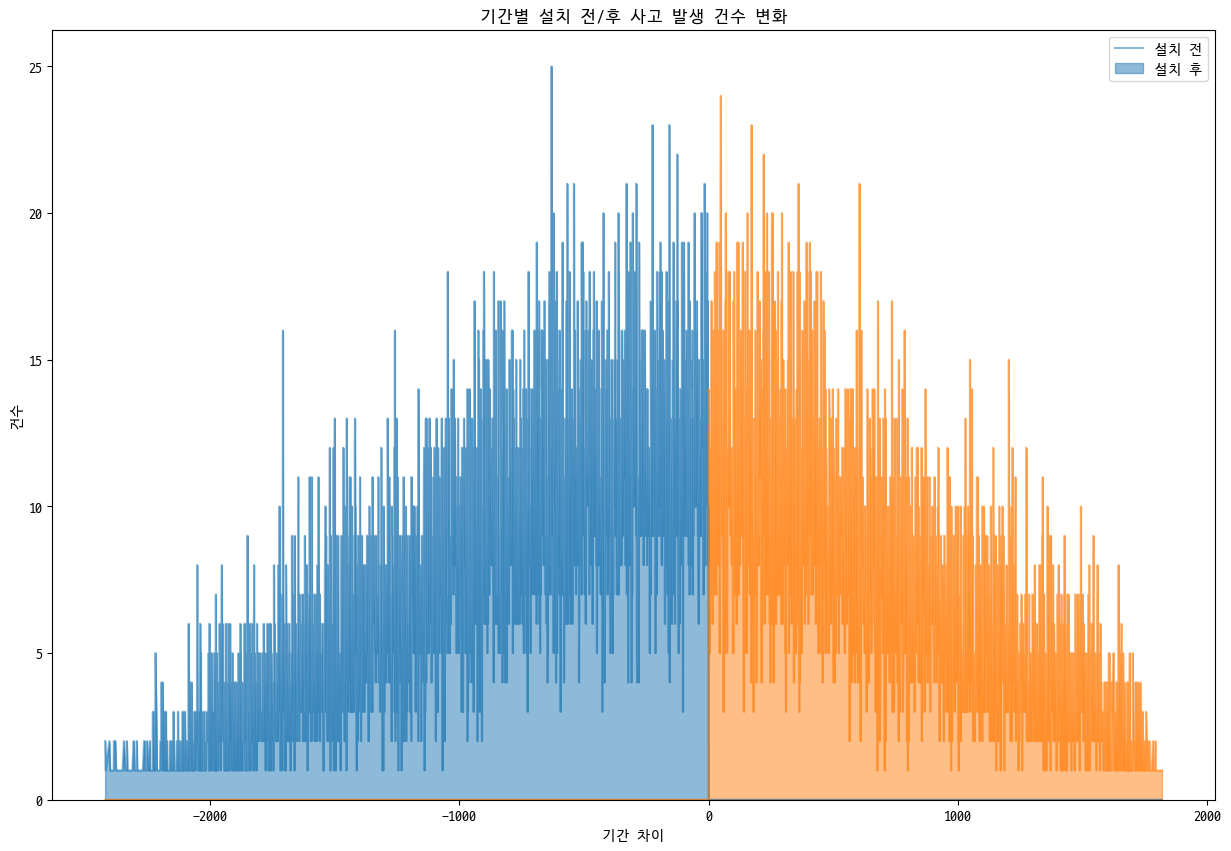

In [103]:
before_installation = tmp[tmp['기간차이'] < 0]
after_installation = tmp[tmp['기간차이'] >= 0]

# 기간 차이를 X 축으로 사용하여 설치 전/후의 사고 발생 건수를 계산합니다.
before_counts = before_installation.groupby('기간차이').size().reset_index(name='설치되기 전 사고 발생 건수')
after_counts = after_installation.groupby('기간차이').size().reset_index(name='설치된 후 사고 발생 건수')

# 기간 차이를 인덱스로 설정하여 하나의 데이터프레임으로 병합합니다.
result = pd.merge(before_counts, after_counts, on='기간차이', how='outer').fillna(0)
result.set_index('기간차이', inplace=True)

# 영역형 그래프로 보여줍니다.
result.plot(kind='area', figsize=(15, 10), stacked=False)
plt.title('기간별 설치 전/후 사고 발생 건수 변화')
plt.xlabel('기간 차이')
plt.ylabel('건수')
plt.legend(['설치 전', '설치 후'])
plt.show()

In [ ]:
m = folium.Map(location=[
    mts['제어기 위도'].mean(),mts['제어기 경도'].mean(),
    ],zoom_start = 10)

for idx in mts.index:
    try:
        folium.CircleMarker(
            location = [mts.loc[idx,'제어기 위도'],mts.loc[idx,'제어기 경도']],
            color = 'red',
            radius = 1,
            popup = '단속장비'
        ).add_to(m)
    except ValueError: pass
for idx in mts.index:
    try:
        folium.CircleMarker(
            location = [mts.loc[idx,'제어기 위도'],mts.loc[idx,'제어기 경도']],
            color = 'yellow',
            radius = 10,
            popup = '단속장비'
        ).add_to(m)
    except ValueError: pass

for idx in gg.index:
    try:
        folium.CircleMarker(
            location = [gg.loc[idx,'GRD_LA'],gg.loc[idx,'GRD_LO']],
            color = 'blue',
            radius = 1,
            popup = '사고발생'
        ).add_to(m)
    except ValueError: pass    

m

In [2]:
acc = pd.read_csv('./use_data/result/mart/TB_ACC_RST_TRD_TRY.csv')
vio = pd.read_csv('./use_data/result/mart/TB_VIO_RST_TRD_TRY.csv')
mst = pd.read_csv('./use_data/result/mart/TB_MTS_MST_GIS.csv')

In [9]:
mst['단속형태'].value_counts()

단속형태
신호위반    333
속도위반     89
구간과속     24
Name: count, dtype: int64

In [13]:
mst[mst['구간그룹명'] != '구간아님']['구간그룹명'].unique()

array(['경부고속도로390', '서해안고속도로318', '신대리구간', '경부하행', '오성면구간'], dtype=object)

In [14]:
acc[acc['단속형태'] == '구간과속']['장비고유구분'].unique()

array(['경부고속도로390', '서해안고속도로318', '오성면구간,신대리구간', '경부하행'], dtype=object)

In [15]:
vio[vio['단속형태'] == '구간과속']['장비고유구분'].unique()

array(['경부고속도로390', '서해안고속도로318', '오성면구간,신대리구간', '경부하행'], dtype=object)